# Project Phase 3 - Modelling and Testing (MSD 10K Clustering)

This notebook implements three clustering algorithms for music recommendation using the Million Song Dataset 10K subset.

## Algorithms Implemented:
1. **K-Means Clustering** - Centroid-based partitioning
2. **Hierarchical (Agglomerative) Clustering** - Tree-based merging
3. **DBSCAN** - Density-based spatial clustering


## 1. Import Libraries

This cell imports all necessary libraries for clustering, evaluation, and visualization.

In [56]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', 50)

## 2. Load and Prepare Data

This cell loads the cleaned dataset from Phase 2 and prepares features for clustering.

**Data preparation steps:**
1. Load `phase2_cleaned_dataset.csv` from Phase 2 folder
2. Select the same 13 features used in Phase 2
3. Apply preprocessing: StandardScaler for numeric, OneHotEncoder for categorical
4. Create feature matrix X for clustering

**Note**: We exclude text columns (artist_name, title, release, genre, file_path) as they are not suitable for distance-based clustering.

In [57]:
# Load dataset from Phase 2
data_path = Path('phase2_cleaned_dataset.csv')

df = pd.read_csv(data_path)
print(f'Loaded {len(df)} songs from Phase 2 dataset')
print(f'Columns: {df.shape[1]} features')

# Define feature sets (same as Phase 2)
numeric_features = ['tempo', 'loudness', 'duration', 'artist_hotttnesss', 'artist_familiarity', 'key_confidence', 'mode_confidence', 'time_signature_confidence', 'danceability', 'energy']
categorical_features = ['key', 'mode', 'time_signature']
metadata_cols = ['song_id', 'track_id', 'artist_name', 'title', 'is_popular']

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Prepare feature matrix
X_raw = df[numeric_features + categorical_features].copy()
X = preprocessor.fit_transform(X_raw)

print(f'Feature matrix shape: {X.shape}')
print(f'Features after encoding: {X.shape[1]} (10 numeric + 3 categorical encoded)')

Loaded 10000 songs from Phase 2 dataset
Columns: 23 features
Feature matrix shape: (10000, 30)
Features after encoding: 30 (10 numeric + 3 categorical encoded)


## 3. Algorithm 1: K-Means Clustering

### How K-Means Works:
K-Means is a **centroid-based clustering algorithm** that partitions data into K clusters by:
1. Randomly initializing K cluster centroids
2. Assigning each point to the nearest centroid (Euclidean distance)
3. Updating centroids as the mean of assigned points
4. Repeating steps 2-3 until convergence

**Advantages**: Simple, fast, scalable to large datasets
**Disadvantages**: Requires specifying K, sensitive to outliers, assumes spherical clusters

### Default Hyperparameters:
- `n_clusters=8`: Number of clusters to form
- `init='k-means++'`: Smart centroid initialization
- `n_init='auto'`: Number of initializations to try
- `max_iter=300`: Maximum iterations
- `algorithm='lloyd'`: Classical EM-style algorithm
- `tol=0.0001`: Relative tolerance for convergence

### Implementation:
First, we use the **Elbow Method** to find the optimal K by plotting inertia vs K.

Running Elbow Method to find optimal K...
K=2: Inertia=86583, Silhouette=0.119
K=3: Inertia=78460, Silhouette=0.110
K=4: Inertia=74309, Silhouette=0.102
K=5: Inertia=70780, Silhouette=0.104
K=6: Inertia=67139, Silhouette=0.100
K=7: Inertia=63734, Silhouette=0.106
K=8: Inertia=61307, Silhouette=0.100
K=9: Inertia=59952, Silhouette=0.095
K=10: Inertia=58326, Silhouette=0.093
K=11: Inertia=57146, Silhouette=0.083
K=12: Inertia=56174, Silhouette=0.080
K=13: Inertia=55334, Silhouette=0.080
K=14: Inertia=54269, Silhouette=0.081


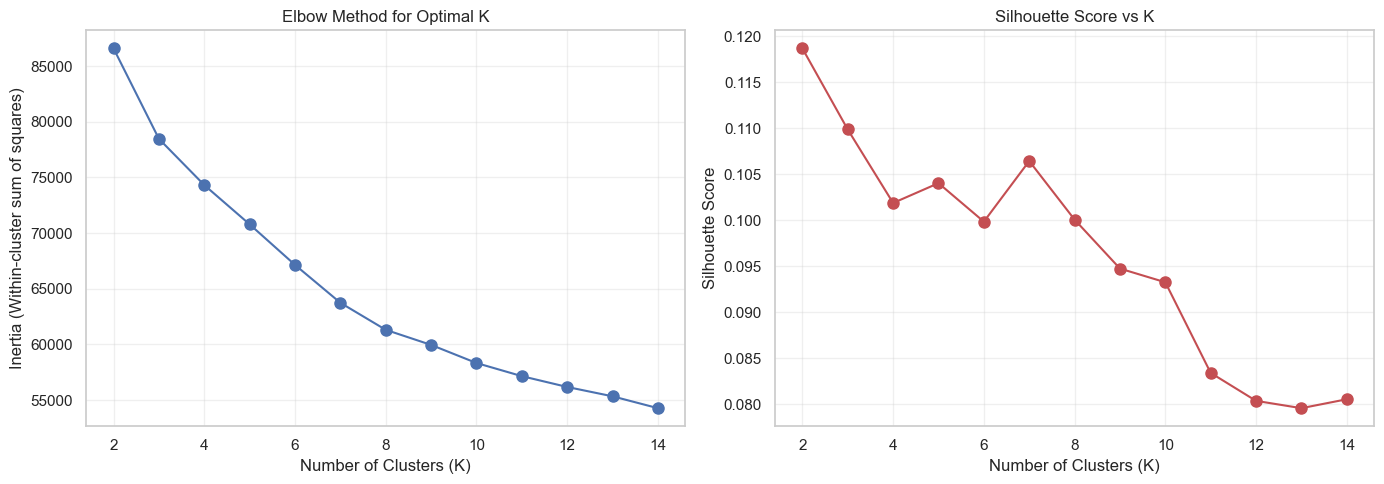

Selected K=6 based on elbow method


In [58]:
# Elbow Method for optimal K selection
print('Running Elbow Method to find optimal K...')

inertias = []
silhouettes = []
K_range = range(2, 15)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    kmeans_temp.fit(X)
    inertias.append(kmeans_temp.inertia_)
    sil_score = silhouette_score(X, kmeans_temp.labels_)
    silhouettes.append(sil_score)
    print(f'K={k}: Inertia={kmeans_temp.inertia_:.0f}, Silhouette={sil_score:.3f}')

# Plot Elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-', markersize=8)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Within-cluster sum of squares)')
ax1.set_title('Elbow Method for Optimal K')
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, silhouettes, 'ro-', markersize=8)
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs K')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Choose optimal K
optimal_k = 6
print(f'Selected K={optimal_k} based on elbow method')

### Fit K-Means with Optimal K

Now we fit the final K-Means model with K=6 and compute evaluation metrics.

In [59]:
# Fit K-Means with optimal K
print('Fitting K-Means with optimal hyperparameters...')

kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    n_init='auto',
    max_iter=300,
    algorithm='lloyd',
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X)

# Store results
df['kmeans_cluster'] = kmeans_labels

# Compute evaluation metrics
kmeans_silhouette = silhouette_score(X, kmeans_labels)
kmeans_davies_bouldin = davies_bouldin_score(X, kmeans_labels)
kmeans_calinski = calinski_harabasz_score(X, kmeans_labels)

print(f'K-Means Results (K={optimal_k}):')
print(f'  Silhouette Score: {kmeans_silhouette:.4f} (higher is better, range: -1 to 1)')
print(f'  Davies-Bouldin Index: {kmeans_davies_bouldin:.4f} (lower is better)')
print(f'  Calinski-Harabasz Score: {kmeans_calinski:.2f} (higher is better)')
print(f'  Inertia: {kmeans.inertia_:.2f} (within-cluster sum of squares)')
print(f'  Iterations to converge: {kmeans.n_iter_}')

# Show cluster distribution
print('Cluster distribution:')
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f'  Cluster {cluster_id}: {count} songs ({count/len(df)*100:.1f}%)')

Fitting K-Means with optimal hyperparameters...
K-Means Results (K=6):
  Silhouette Score: 0.0999 (higher is better, range: -1 to 1)
  Davies-Bouldin Index: 2.0206 (lower is better)
  Calinski-Harabasz Score: 944.77 (higher is better)
  Inertia: 67138.87 (within-cluster sum of squares)
  Iterations to converge: 49
Cluster distribution:
  Cluster 0: 1154 songs (11.5%)
  Cluster 1: 2051 songs (20.5%)
  Cluster 2: 2290 songs (22.9%)
  Cluster 3: 434 songs (4.3%)
  Cluster 4: 2478 songs (24.8%)
  Cluster 5: 1593 songs (15.9%)


## 4. Algorithm 2: Hierarchical (Agglomerative) Clustering

### How Hierarchical Clustering Works:
Hierarchical clustering creates a **tree-like structure (dendrogram)** of clusters by:
1. Starting with each point as its own cluster
2. Iteratively merging the closest pair of clusters
3. Continuing until all points are in one cluster
4. Cutting the dendrogram at a chosen height gives K clusters

**Linkage methods** determine how to measure cluster distance:
- `ward`: Minimizes variance (default, works well for most data)
- `complete`: Maximum distance between any two points
- `average`: Average distance between all pairs
- `single`: Minimum distance between any two points

**Advantages**: No need to specify K initially, produces interpretable dendrogram
**Disadvantages**: Computationally expensive (O(n3)), not scalable to large datasets

### Default Hyperparameters:
- `n_clusters=None`: Cut the tree at this level
- `metric='euclidean'`: Distance metric
- `linkage='ward'`: Linkage criterion (ward works only with euclidean)
- `distance_threshold=None`: Distance to cut the tree
- `compute_distances=False`: Store distances for dendrogram

Creating dendrogram for hierarchical clustering...


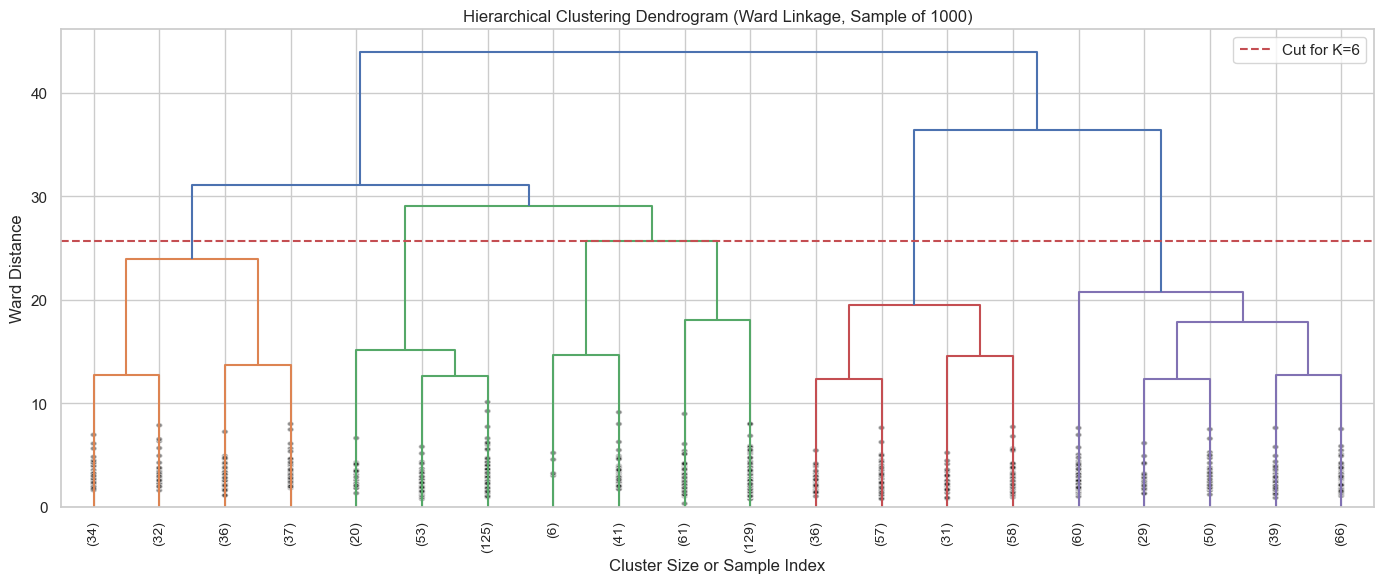

Dendrogram shows the hierarchical structure. Cutting at the red line gives K=6 clusters.


In [60]:
# Create dendrogram (sample 1000 points for visualization)
print('Creating dendrogram for hierarchical clustering...')

# Sample for dendrogram (full data too large for visualization)
np.random.seed(42)
sample_indices = np.random.choice(len(X), size=min(1000, len(X)), replace=False)
X_sample = X[sample_indices]

# Compute linkage
linkage_matrix = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 6))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, Sample of 1000)')
plt.xlabel('Cluster Size or Sample Index')
plt.ylabel('Ward Distance')
cut_height = linkage_matrix[-optimal_k+1, 2] if optimal_k > 1 else linkage_matrix[-1, 2]
plt.axhline(y=cut_height, color='r', linestyle='--', label=f'Cut for K={optimal_k}')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Dendrogram shows the hierarchical structure. Cutting at the red line gives K={optimal_k} clusters.')

### Fit Agglomerative Clustering with Optimal K

Now we fit the final Agglomerative Clustering model with the same K=6 for fair comparison.

In [61]:
# Fit Agglomerative Clustering
print('Fitting Agglomerative Clustering...')

agg_clustering = AgglomerativeClustering(
    n_clusters=optimal_k,
    metric='euclidean',
    linkage='ward',
    compute_distances=True
)

agg_labels = agg_clustering.fit_predict(X)

# Store results
df['agg_cluster'] = agg_labels

# Compute evaluation metrics
agg_silhouette = silhouette_score(X, agg_labels)
agg_davies_bouldin = davies_bouldin_score(X, agg_labels)
agg_calinski = calinski_harabasz_score(X, agg_labels)

print(f'Agglomerative Clustering Results (K={optimal_k}):')
print(f'  Silhouette Score: {agg_silhouette:.4f}')
print(f'  Davies-Bouldin Index: {agg_davies_bouldin:.4f}')
print(f'  Calinski-Harabasz Score: {agg_calinski:.2f}')

# Show cluster distribution
print('Cluster distribution:')
cluster_counts = pd.Series(agg_labels).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f'  Cluster {cluster_id}: {count} songs ({count/len(df)*100:.1f}%)')

Fitting Agglomerative Clustering...
Agglomerative Clustering Results (K=6):
  Silhouette Score: 0.0510
  Davies-Bouldin Index: 2.4632
  Calinski-Harabasz Score: 643.14
Cluster distribution:
  Cluster 0: 2452 songs (24.5%)
  Cluster 1: 3012 songs (30.1%)
  Cluster 2: 1948 songs (19.5%)
  Cluster 3: 584 songs (5.8%)
  Cluster 4: 488 songs (4.9%)
  Cluster 5: 1516 songs (15.2%)


## 5. Algorithm 3: DBSCAN (Density-Based Spatial Clustering)

### How DBSCAN Works:
DBSCAN is a **density-based algorithm** that groups together points in high-density regions and marks outliers as noise:

1. **Core points**: Points with at least `min_samples` neighbors within `eps` distance
2. **Border points**: Points within `eps` of a core point but not core themselves
3. **Noise points**: All other points (assigned label -1)
4. Clusters are formed by connecting core points that are density-reachable

**Advantages**: Discovers arbitrarily shaped clusters, robust to outliers, no need to specify K
**Disadvantages**: Sensitive to `eps` and `min_samples`, struggles with varying density clusters

### Default Hyperparameters:
- `eps=0.5`: Maximum distance between two samples to be considered neighbors
- `min_samples=5`: Minimum samples in neighborhood for core point
- `metric='euclidean'`: Distance metric
- `algorithm='auto'`: Algorithm to compute nearest neighbors
- `leaf_size=30`: Leaf size for KD tree or ball tree
- `p=None`: Power for Minkowski metric

### Implementation:
First, we use the **K-Distance Graph** method to find optimal `eps`.

Creating K-Distance Graph to find optimal eps...


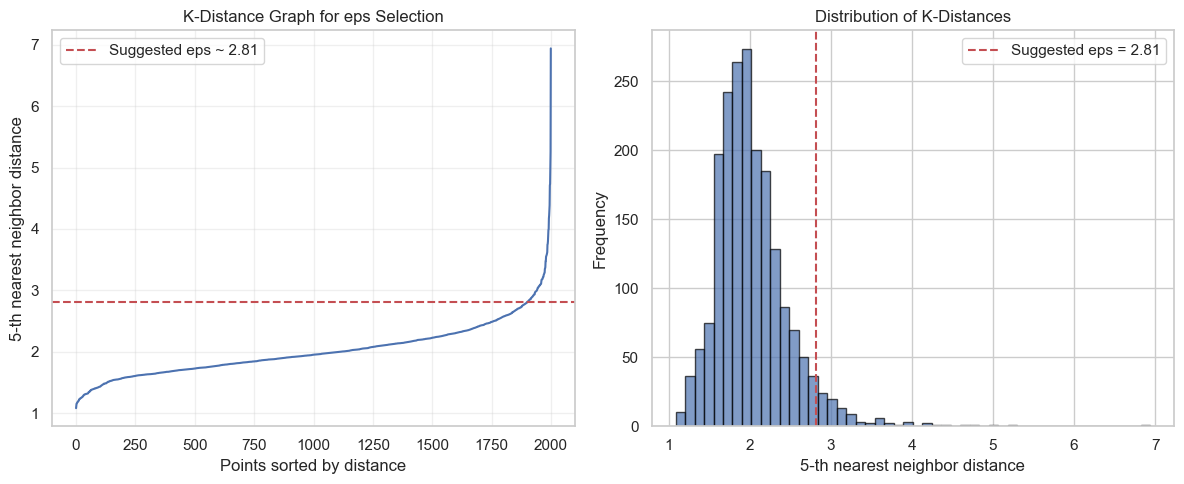

Suggested eps from K-Distance graph: 2.81
Using min_samples = 5


In [62]:
# K-Distance Graph to find optimal eps
print('Creating K-Distance Graph to find optimal eps...')

# Sample for k-distance computation (DBSCAN is O(n2), so we sample)
np.random.seed(42)
sample_size = min(2000, len(X))
sample_indices = np.random.choice(len(X), size=sample_size, replace=False)
X_dbscan_sample = X[sample_indices]

# Compute k-distances (k = min_samples - 1)
min_samples = 5
k = min_samples - 1

neighbors = NearestNeighbors(n_neighbors=k+1)
neighbors_fit = neighbors.fit(X_dbscan_sample)
distances, indices = neighbors_fit.kneighbors(X_dbscan_sample)

# Get k-th nearest neighbor distance for each point
k_distances = distances[:, k]
k_distances = np.sort(k_distances)

# Plot k-distance graph
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(len(k_distances)), k_distances, 'b-')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{k+1}-th nearest neighbor distance')
plt.title('K-Distance Graph for eps Selection')
plt.grid(True, alpha=0.3)
suggested_eps = k_distances[int(len(k_distances) * 0.95)]
plt.axhline(y=suggested_eps, color='r', linestyle='--', label=f'Suggested eps ~ {suggested_eps:.2f}')
plt.legend()

# Distribution of k-distances
plt.subplot(1, 2, 2)
plt.hist(k_distances, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel(f'{k+1}-th nearest neighbor distance')
plt.ylabel('Frequency')
plt.title('Distribution of K-Distances')
plt.axvline(x=suggested_eps, color='r', linestyle='--', label=f'Suggested eps = {suggested_eps:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

print(f'Suggested eps from K-Distance graph: {suggested_eps:.2f}')
print(f'Using min_samples = {min_samples}')

### Fit DBSCAN with Optimal Parameters

Now we fit DBSCAN. Note: DBSCAN discovers clusters automatically and may find a different number than K=6.

In [63]:
# Fit DBSCAN on full dataset
print('Fitting DBSCAN with optimal hyperparameters...')

# Use eps from k-distance analysis
eps = max(0.5, suggested_eps)

dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples,
    metric='euclidean',
    algorithm='auto',
    leaf_size=30
)

dbscan_labels = dbscan.fit_predict(X)

# Store results
df['dbscan_cluster'] = dbscan_labels

# Count clusters and noise
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
noise_percent = (n_noise / len(dbscan_labels)) * 100

print(f'DBSCAN Results:')
print(f'  Number of clusters found: {n_clusters}')
print(f'  Number of noise points: {n_noise} ({noise_percent:.1f}%)')
print(f'  eps used: {eps:.2f}')
print(f'  min_samples used: {min_samples}')

# Show cluster distribution
print('Cluster distribution:')
cluster_counts = pd.Series(dbscan_labels).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    label = f'Cluster {cluster_id}' if cluster_id != -1 else 'Noise (-1)'
    print(f'  {label}: {count} songs ({count/len(df)*100:.1f}%)')

# Compute evaluation metrics (excluding noise points)
dbscan_silhouette = None
dbscan_davies_bouldin = None
dbscan_calinski = None

if n_clusters >= 2 and n_noise < len(dbscan_labels):
    non_noise_mask = dbscan_labels != -1
    n_non_noise = np.sum(non_noise_mask)
    if n_non_noise > n_clusters:
        try:
            dbscan_silhouette = silhouette_score(X[non_noise_mask], dbscan_labels[non_noise_mask])
            dbscan_davies_bouldin = davies_bouldin_score(X[non_noise_mask], dbscan_labels[non_noise_mask])
            dbscan_calinski = calinski_harabasz_score(X[non_noise_mask], dbscan_labels[non_noise_mask])
            print(f'Metrics (excluding noise points):')
            print(f'  Silhouette Score: {dbscan_silhouette:.4f}')
            print(f'  Davies-Bouldin Index: {dbscan_davies_bouldin:.4f}')
            print(f'  Calinski-Harabasz Score: {dbscan_calinski:.2f}')
        except ValueError as e:
            print(f'Could not compute metrics: {e}')
    else:
        print('Not enough non-noise points for reliable metrics')
else:
    print(f'Cannot compute metrics: need at least 2 clusters, found {n_clusters}')

Fitting DBSCAN with optimal hyperparameters...
DBSCAN Results:
  Number of clusters found: 1
  Number of noise points: 70 (0.7%)
  eps used: 2.81
  min_samples used: 5
Cluster distribution:
  Noise (-1): 70 songs (0.7%)
  Cluster 0: 9930 songs (99.3%)
Cannot compute metrics: need at least 2 clusters, found 1


## 6. Model Comparison

Now we compare all three clustering algorithms using standard evaluation metrics.

MODEL COMPARISON SUMMARY
   Algorithm           Type  Clusters Silhouette Score Davies-Bouldin Index Calinski-Harabasz Noise/Outliers
     K-Means Centroid-based         6           0.0999               2.0206            944.77           None
Hierarchical     Tree-based         6            0.051               2.4632            643.14           None
      DBSCAN  Density-based         1              N/A                  N/A               N/A      70 (0.7%)


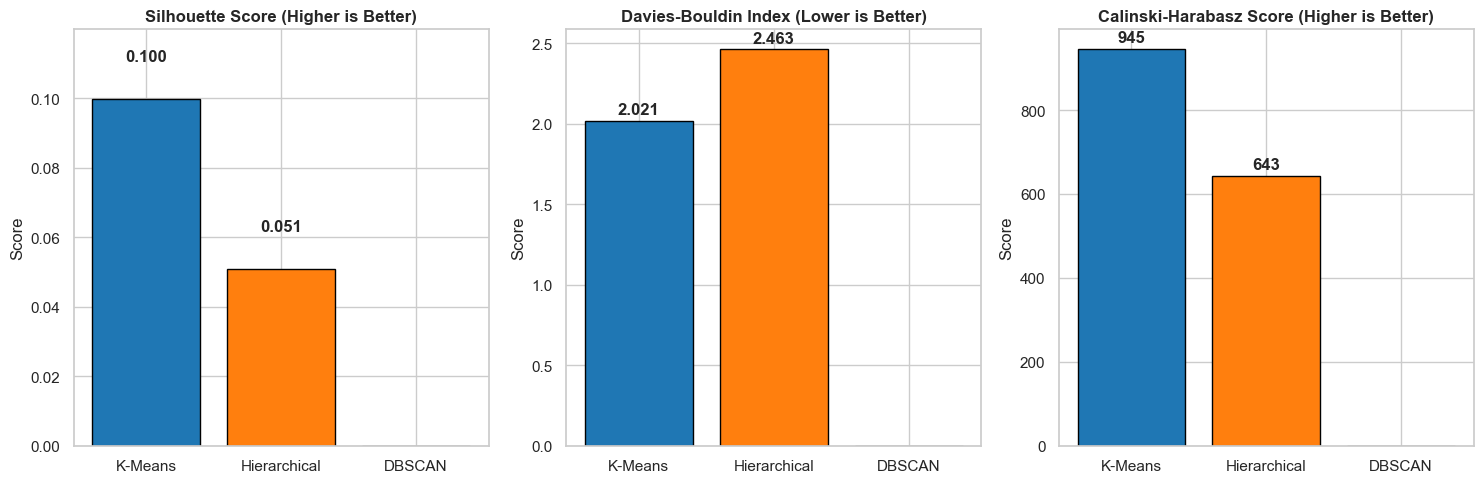

Metric Interpretations:
  * Silhouette Score: Measures how similar a point is to its own cluster vs other clusters (-1 to 1)
  * Davies-Bouldin Index: Average similarity ratio of each cluster with its most similar cluster (lower is better)
  * Calinski-Harabasz: Ratio of between-cluster dispersion to within-cluster dispersion (higher is better)


In [64]:
# Create comparison table
sil_dbscan = round(dbscan_silhouette, 4) if dbscan_silhouette is not None else 'N/A'
db_dbscan = round(dbscan_davies_bouldin, 4) if dbscan_davies_bouldin is not None else 'N/A'
ch_dbscan = round(dbscan_calinski, 2) if dbscan_calinski is not None else 'N/A'

comparison_data = {
    'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'Type': ['Centroid-based', 'Tree-based', 'Density-based'],
    'Clusters': [optimal_k, optimal_k, n_clusters],
    'Silhouette Score': [round(kmeans_silhouette, 4), round(agg_silhouette, 4), sil_dbscan],
    'Davies-Bouldin Index': [round(kmeans_davies_bouldin, 4), round(agg_davies_bouldin, 4), db_dbscan],
    'Calinski-Harabasz': [round(kmeans_calinski, 2), round(agg_calinski, 2), ch_dbscan],
    'Noise/Outliers': ['None', 'None', f'{n_noise} ({noise_percent:.1f}%)']
}

comparison_df = pd.DataFrame(comparison_data)

print('=' * 80)
print('MODEL COMPARISON SUMMARY')
print('=' * 80)
print(comparison_df.to_string(index=False))
print('=' * 80)

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

algorithms = ['K-Means', 'Hierarchical', 'DBSCAN']
sil_scores = [kmeans_silhouette, agg_silhouette, dbscan_silhouette if dbscan_silhouette is not None else 0]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

axes[0].bar(algorithms, sil_scores, color=colors, edgecolor='black')
axes[0].set_title('Silhouette Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score')
max_sil = max([s for s in sil_scores if s > 0]) if any(s > 0 for s in sil_scores) else 1
axes[0].set_ylim(0, max_sil * 1.2)
for i, v in enumerate(sil_scores):
    if v > 0:
        axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

db_scores = [kmeans_davies_bouldin, agg_davies_bouldin, dbscan_davies_bouldin if dbscan_davies_bouldin is not None else 0]

axes[1].bar(algorithms, db_scores, color=colors, edgecolor='black')
axes[1].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score')
for i, v in enumerate(db_scores):
    if v > 0:
        axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

ch_scores = [kmeans_calinski, agg_calinski, dbscan_calinski if dbscan_calinski is not None else 0]

axes[2].bar(algorithms, ch_scores, color=colors, edgecolor='black')
axes[2].set_title('Calinski-Harabasz Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Score')
max_ch = max([s for s in ch_scores if s > 0]) if any(s > 0 for s in ch_scores) else 1
for i, v in enumerate(ch_scores):
    if v > 0:
        axes[2].text(i, v + max_ch*0.01, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print('Metric Interpretations:')
print('  * Silhouette Score: Measures how similar a point is to its own cluster vs other clusters (-1 to 1)')
print('  * Davies-Bouldin Index: Average similarity ratio of each cluster with its most similar cluster (lower is better)')
print('  * Calinski-Harabasz: Ratio of between-cluster dispersion to within-cluster dispersion (higher is better)')

## 7. Music Recommendation System Demonstration

We implement recommendation systems based on **all three clustering algorithms**:

**Recommendation Logic:**
1. Find the cluster of the input song for each algorithm
2. Return other songs from the same cluster
3. Sort by Euclidean distance (closer = more similar)

This approach assumes songs in the same cluster share similar audio characteristics.

**Note:** For DBSCAN, songs marked as noise (-1) will use the nearest cluster centroid for recommendations.

In [65]:
def find_similar_songs(song_identifier, cluster_type='kmeans', n_recommendations=5, 
                       feature_matrix=X, data_df=df, cluster_labels=None):
    """
    Find songs similar to the given song based on clustering.
    
    Parameters:
    -----------
    song_identifier : str or int
        Either a song_id, track_id, or index in the dataframe
    cluster_type : str
        'kmeans', 'hierarchical', or 'dbscan'
    n_recommendations : int
        Number of similar songs to return
    feature_matrix : numpy array
        The preprocessed feature matrix
    data_df : DataFrame
        The dataframe with song metadata
    cluster_labels : array
        Cluster labels (auto-detected if None)
    
    Returns:
    --------
    DataFrame with recommended songs
    """
    # Determine cluster column
    if cluster_type == 'kmeans':
        cluster_col = 'kmeans_cluster'
        cluster_title = 'K-Means'
    elif cluster_type == 'hierarchical':
        cluster_col = 'agg_cluster'
        cluster_title = 'Hierarchical'
    elif cluster_type == 'dbscan':
        cluster_col = 'dbscan_cluster'
        cluster_title = 'DBSCAN'
    else:
        raise ValueError(f"Unknown cluster_type: {cluster_type}")
    
    # Get cluster labels
    if cluster_labels is None:
        cluster_labels = data_df[cluster_col].values
    
    # Find the song index
    if isinstance(song_identifier, int):
        song_idx = song_identifier
    else:
        mask = (data_df['song_id'] == song_identifier) | (data_df['track_id'] == song_identifier)
        if mask.sum() == 0:
            raise ValueError(f'Song {song_identifier} not found in dataset')
        song_idx = data_df[mask].index[0]
    
    # Get the song's cluster
    song_cluster = cluster_labels[song_idx]
    
    # Handle DBSCAN noise points (cluster = -1)
    if cluster_type == 'dbscan' and song_cluster == -1:
        # For noise points, find nearest non-noise point
        non_noise_mask = cluster_labels != -1
        if np.sum(non_noise_mask) == 0:
            return pd.DataFrame(), cluster_title, -1
        
        # Find nearest non-noise point
        song_features = feature_matrix[song_idx].reshape(1, -1)
        non_noise_indices = np.where(non_noise_mask)[0]
        non_noise_features = feature_matrix[non_noise_indices]
        distances_to_non_noise = cdist(song_features, non_noise_features, metric='euclidean')[0]
        nearest_idx = non_noise_indices[np.argmin(distances_to_non_noise)]
        song_cluster = cluster_labels[nearest_idx]
        print(f'    (Note: Input song was noise, using nearest cluster {song_cluster})')
    
    # Get all songs in the same cluster
    same_cluster_mask = cluster_labels == song_cluster
    same_cluster_indices = np.where(same_cluster_mask)[0].tolist()
    
    # Remove the input song itself
    same_cluster_indices = [idx for idx in same_cluster_indices if idx != song_idx]
    
    if len(same_cluster_indices) == 0:
        return pd.DataFrame(), cluster_title, song_cluster
    
    # Calculate distances to all songs in the same cluster
    song_features = feature_matrix[song_idx].reshape(1, -1)
    cluster_features = feature_matrix[same_cluster_indices]
    distances = cdist(song_features, cluster_features, metric='euclidean')[0]
    
    # Get indices of closest songs
    closest_indices = np.argsort(distances)[:n_recommendations]
    recommended_df_indices = [same_cluster_indices[i] for i in closest_indices]
    
    # Create recommendations dataframe
    recommendations = data_df.iloc[recommended_df_indices][[
        'artist_name', 'title', 'tempo', 'loudness', cluster_col
    ]].copy()
    recommendations['similarity_distance'] = distances[closest_indices]
    
    return recommendations.reset_index(drop=True), cluster_title, song_cluster

# DEMO: Test recommendation system with ALL THREE algorithms
print('=' * 80)
print('MUSIC RECOMMENDATION SYSTEM - ALL THREE MODELS')
print('=' * 80)

# Pick a random song
np.random.seed(42)
sample_song_idx = np.random.choice(len(df))
sample_song = df.iloc[sample_song_idx]

print(f'\n=== INPUT SONG ===')
print(f'Artist: {sample_song["artist_name"]}')
print(f'Title: {sample_song["title"]}')
print(f'Tempo: {sample_song["tempo"]:.1f} BPM')
print(f'Loudness: {sample_song["loudness"]:.2f} dB')
print(f'\nCluster assignments:')
print(f'  K-Means: Cluster {sample_song["kmeans_cluster"]}')
print(f'  Hierarchical: Cluster {sample_song["agg_cluster"]}')
print(f'  DBSCAN: Cluster {sample_song["dbscan_cluster"]}')

# Test all three algorithms
algorithms = ['kmeans', 'hierarchical', 'dbscan']

for algo in algorithms:
    print(f'\n=== RECOMMENDATIONS FROM {algo.upper()} CLUSTERING ===')
    print('-' * 80)
    
    try:
        recs, algo_name, cluster_id = find_similar_songs(
            sample_song_idx, cluster_type=algo, n_recommendations=5
        )
        
        if len(recs) == 0:
            print(f'No similar songs found in {algo_name} cluster {cluster_id}')
        else:
            print(f'Cluster: {cluster_id} ({len(recs)} similar songs available)')
            print()
            for idx, row in recs.iterrows():
                print(f'{idx+1}. {row["artist_name"]} - {row["title"]}')
                print(f'   Tempo: {row["tempo"]:.1f} BPM | Loudness: {row["loudness"]:.2f} dB | Distance: {row["similarity_distance"]:.3f}')
    except Exception as e:
        print(f'Error with {algo}: {e}')

print('=' * 80)

# Comparison summary
print('\n=== COMPARISON SUMMARY ===')
print('Model Performance for Recommendations:')
print('  * K-Means: Fast, works well with spherical clusters')
print('  * Hierarchical: More flexible cluster shapes, deterministic')
print('  * DBSCAN: Can identify outliers, discovers irregular shapes')
print('=' * 80)

MUSIC RECOMMENDATION SYSTEM - ALL THREE MODELS

=== INPUT SONG ===
Artist: Terry Callier
Title: Holdin' On
Tempo: 95.9 BPM
Loudness: -10.86 dB

Cluster assignments:
  K-Means: Cluster 2
  Hierarchical: Cluster 0
  DBSCAN: Cluster 0

=== RECOMMENDATIONS FROM KMEANS CLUSTERING ===
--------------------------------------------------------------------------------
Cluster: 2 (5 similar songs available)

1. Ginny Owens - Long Way Home
   Tempo: 120.2 BPM | Loudness: -12.10 dB | Distance: 1.383
2. The Elders - Send a Prayer
   Tempo: 111.4 BPM | Loudness: -7.03 dB | Distance: 1.386
3. Elena - Satan Kingsize
   Tempo: 116.1 BPM | Loudness: -9.72 dB | Distance: 1.390
4. Poncho Sanchez - El Jamaiquino
   Tempo: 125.6 BPM | Loudness: -13.46 dB | Distance: 1.407
5. Alias - After All The Love Is Gone
   Tempo: 120.1 BPM | Loudness: -10.22 dB | Distance: 1.414

=== RECOMMENDATIONS FROM HIERARCHICAL CLUSTERING ===
--------------------------------------------------------------------------------
Cluster

## 8. Export Results

Save cluster assignments to CSV for submission and further analysis.

In [66]:
# Export results
output_df = df[['song_id', 'track_id', 'artist_name', 'title', 'kmeans_cluster', 'agg_cluster', 'dbscan_cluster', 'is_popular']].copy()

output_path = Path('phase3_cluster_assignments.csv')
output_df.to_csv(output_path, index=False)

print('=' * 80)
print('EXPORT COMPLETE')
print('=' * 80)
print(f'Saved: {output_path.resolve()}')
print(f'File contains cluster assignments for {len(output_df)} songs:')
print(f'  - K-Means cluster: {output_df["kmeans_cluster"].nunique()} unique values')
print(f'  - Hierarchical cluster: {output_df["agg_cluster"].nunique()} unique values')
print(f'  - DBSCAN cluster: {output_df["dbscan_cluster"].nunique()} unique values (including noise=-1)')

# Handle None values for report
dbscan_sil_str = f'{dbscan_silhouette:.4f}' if dbscan_silhouette is not None else 'N/A'

# Create summary report
summary_report = f'''
PHASE 3 - MODELLING AND TESTING SUMMARY
========================================

Dataset: Million Song Dataset 10K subset
Total songs: {len(df)}
Features used: {X.shape[1]} (10 numeric + 3 categorical encoded)

ALGORITHMS IMPLEMENTED:
1. K-Means Clustering
   - Type: Centroid-based
   - Optimal K: {optimal_k}
   - Silhouette Score: {kmeans_silhouette:.4f}
   - Davies-Bouldin Index: {kmeans_davies_bouldin:.4f}
   - Calinski-Harabasz Score: {kmeans_calinski:.2f}

2. Hierarchical Clustering
   - Type: Agglomerative, Ward linkage
   - K: {optimal_k}
   - Silhouette Score: {agg_silhouette:.4f}
   - Davies-Bouldin Index: {agg_davies_bouldin:.4f}
   - Calinski-Harabasz Score: {agg_calinski:.2f}

3. DBSCAN
   - Type: Density-based
   - Eps: {eps:.2f}
   - Min samples: {min_samples}
   - Clusters found: {n_clusters}
   - Noise points: {n_noise} ({noise_percent:.1f}%)
   - Silhouette Score: {dbscan_sil_str}

FILES GENERATED:
- phase3_cluster_assignments.csv: Song IDs with cluster assignments
- This notebook with all code and explanations
'''

print('\n' + summary_report)

# Save summary report
report_path = Path('phase3_summary_report.txt')
with open(report_path, 'w') as f:
    f.write(summary_report)

print(f'Summary report saved: {report_path.resolve()}')

EXPORT COMPLETE
Saved: /Users/trieule/School/DATA480/modelling and testing/Project Phase 3/phase3_cluster_assignments.csv
File contains cluster assignments for 10000 songs:
  - K-Means cluster: 6 unique values
  - Hierarchical cluster: 6 unique values
  - DBSCAN cluster: 2 unique values (including noise=-1)


PHASE 3 - MODELLING AND TESTING SUMMARY

Dataset: Million Song Dataset 10K subset
Total songs: 10000
Features used: 30 (10 numeric + 3 categorical encoded)

ALGORITHMS IMPLEMENTED:
1. K-Means Clustering
   - Type: Centroid-based
   - Optimal K: 6
   - Silhouette Score: 0.0999
   - Davies-Bouldin Index: 2.0206
   - Calinski-Harabasz Score: 944.77

2. Hierarchical Clustering
   - Type: Agglomerative, Ward linkage
   - K: 6
   - Silhouette Score: 0.0510
   - Davies-Bouldin Index: 2.4632
   - Calinski-Harabasz Score: 643.14

3. DBSCAN
   - Type: Density-based
   - Eps: 2.81
   - Min samples: 5
   - Clusters found: 1
   - Noise points: 70 (0.7%)
   - Silhouette Score: N/A

FILES GENERA

## End of Phase 3

---

**Team Members:**
- Vik Dayal
- Nathaniel Ola Ogunleye
- Osele Adeoye
- Huynh Hai Trieu Le

**Submission Files:**
1. `Phase3_Modelling_and_Testing.ipynb` - This notebook
2. `phase3_cluster_assignments.csv` - Cluster assignments for all 10K songs
3. `phase3_summary_report.txt` - Summary of results
4. `requirements.txt` - Python dependencies